In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("cloud_server_resource_consumption_dataset.csv")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
print(df.shape)
print(df.head())

(10000, 25)
   hour_of_day  day_of_week  is_weekend  is_peak_hour  active_users  \
0            6            0           0             0          3040   
1           19            1           0             1          4693   
2           14            5           1             0          1199   
3           10            6           1             0           112   
4            7            1           0             0          4989   

   requests_per_minute  avg_request_size_kb  api_calls_per_minute  \
0          3528.593163            75.849039            786.849818   
1          3758.887203            95.257798           1056.615844   
2          1476.103998            66.247144            383.402379   
3           167.792816            73.781887             33.884015   
4          5010.979711             6.535530           2083.248968   

   db_queries_per_minute  background_jobs_count  ...  network_in_mbps  \
0             406.162846                      2  ...        36.268301   


In [40]:
correlation = df.corr(numeric_only=True)
print(correlation["cpu_usage_percent"].sort_values(ascending=False))

cpu_usage_percent         1.000000
requests_per_minute       0.919786
active_users              0.899578
network_in_mbps           0.859785
network_out_mbps          0.844930
api_calls_per_minute      0.802896
avg_response_time_ms      0.798162
db_queries_per_minute     0.771569
disk_read_ops             0.692226
disk_write_ops            0.650383
memory_usage_percent      0.291561
background_jobs_count     0.085877
is_peak_hour              0.081923
scheduled_job_flag        0.069398
error_rate_percent        0.064238
hour_of_day               0.049134
avg_request_size_kb      -0.001616
container_count          -0.003447
allocated_cpu_cores      -0.006298
allocated_memory_gb      -0.006767
cache_hit_ratio          -0.007733
is_weekend               -0.008449
running_services_count   -0.011355
release_day_flag         -0.015116
day_of_week              -0.015293
Name: cpu_usage_percent, dtype: float64


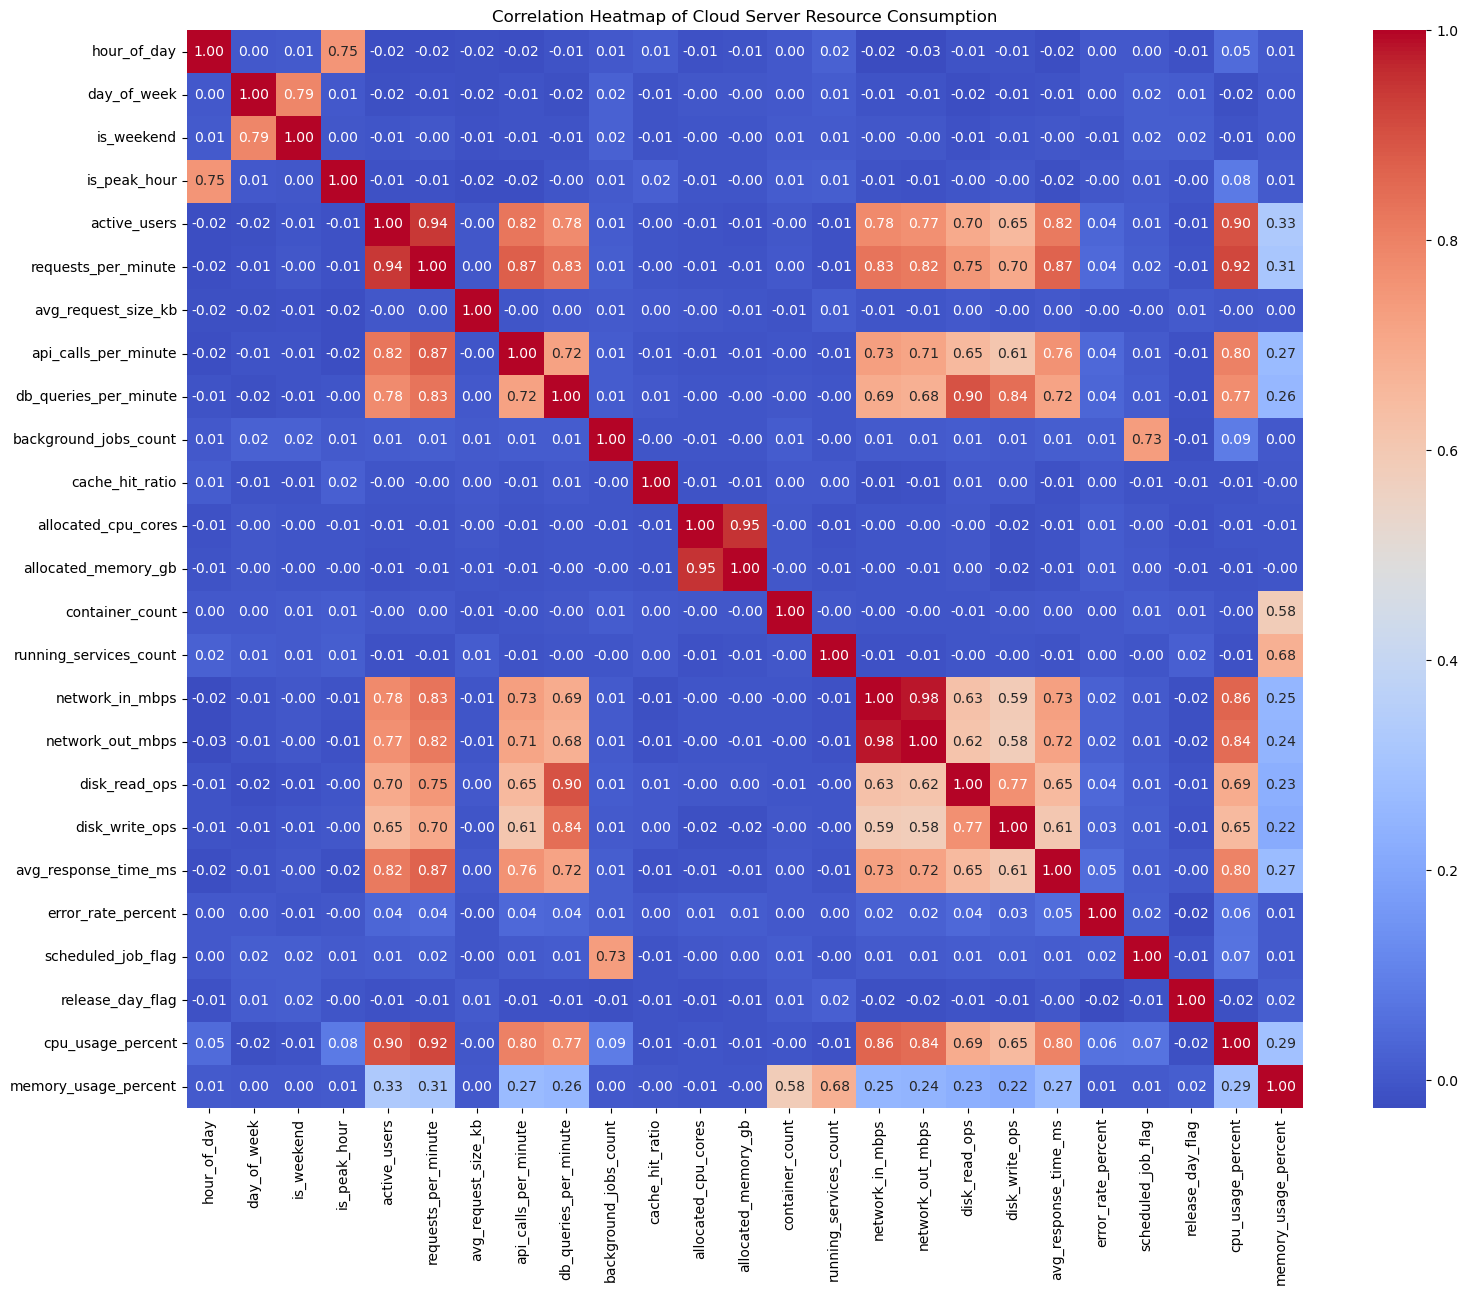

In [44]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(18, 14))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Cloud Server Resource Consumption")
plt.show()

In [43]:
target = "cpu_usage_percent"
correlation = df.corr(numeric_only=True)
corr_target = correlation[target].abs()
selected_features = corr_target[
    corr_target >= 0.5
].index.tolist()
selected_features.remove(target)

print("Correlation Selected Features:")
print(selected_features)

Correlation Selected Features:
['active_users', 'requests_per_minute', 'api_calls_per_minute', 'db_queries_per_minute', 'network_in_mbps', 'network_out_mbps', 'disk_read_ops', 'disk_write_ops', 'avg_response_time_ms']


In [47]:
selected_features = corr_target[
    corr_target.abs() >= 0.5
].index.tolist()
selected_features.remove(target)
print("Strongly Related Features:")
print(selected_features)

Strongly Related Features:
['active_users', 'requests_per_minute', 'api_calls_per_minute', 'db_queries_per_minute', 'network_in_mbps', 'network_out_mbps', 'disk_read_ops', 'disk_write_ops', 'avg_response_time_ms']


In [13]:
df_fe = df.copy()
df_fe['requests_per_user'] = df_fe['requests_per_minute'] / (df_fe['active_users'] + 1)

In [16]:
df_fe['api_per_request'] = df_fe['api_calls_per_minute'] / (df_fe['requests_per_minute'] + 1)

In [18]:
df_fe['db_per_request'] = df_fe['db_queries_per_minute'] / (df_fe['requests_per_minute'] + 1)

In [19]:
df_fe['cpu_per_container'] = df_fe['cpu_usage_percent'] / (df_fe['container_count'] + 1)

In [23]:
df_fe['network_ratio'] = df_fe['network_in_mbps'] / (df_fe['network_out_mbps'] + 1)

In [33]:
df_fe['disk_efficiency'] = df_fe['disk_read_ops'] / (df_fe['disk_write_ops'] + 1)

In [32]:
df_fe['response efficiency'] = df_fe['requests_per_minute'] / (df_fe['avg_response_time_ms'] +1)

In [ ]:
df_fe['cpu_utilization_ratio=df_fe']cpu_usage_percent/ (dt_fe 'allocated_cpu_cores + 11
df_fe'memory_utilization_ratio" df_fe['memory_usage_percent'] / (df_fel'allocated_memory_gb+1)

In [31]:
y = df_fe['cpu_usage_percent']
X = df_fe.drop(columns=['cpu_usage_percent'])

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [37]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 6.530291117807605
RMSE: 8.274799960525828
R2 Score: 0.9115207345212342
